In [1]:
import pandas as pd 
import sqlite3
from pandas.plotting import scatter_matrix

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
SELECT
    t.uid,
    AVG((CAST(strftime('%s', t.first_commit_ts) AS INT) - d.deadlines) / 3600) AS avg_diff,
    (   SELECT COUNT(*)
        FROM checker c
        WHERE c.uid = t.uid AND c.labname != 'project1'
    ) AS commits,
    (
        SELECT COUNT(*)
        FROM pageviews p
        WHERE p.uid = t.uid
    ) AS pageviews
FROM test t
    JOIN deadlines d ON t.labname = d.labs
WHERE t.labname != 'project1'
GROUP BY t.uid;
"""

In [4]:
df = pd.read_sql(query, conn)

df.head()

,uid,avg_diff,commits,pageviews
0,user_1,-64.400000,62,28
1,user_10,-74.800000,20,89
2,user_14,-159.000000,61,143
3,user_17,-61.600000,51,47
4,user_18,-5.666667,5,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   uid        11 non-null     object 
 1   avg_diff   11 non-null     float64
 2   commits    11 non-null     int64  
 3   pageviews  11 non-null     int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 484.0+ bytes


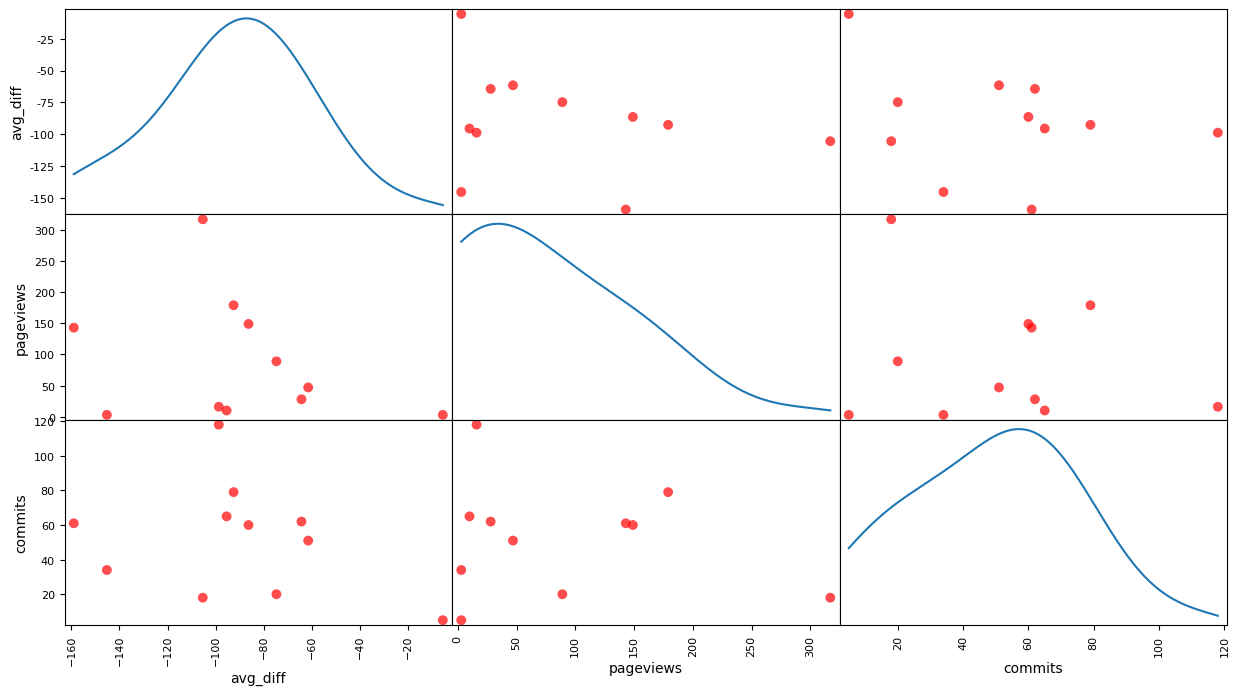

In [6]:
axes = scatter_matrix(
    df[['avg_diff', 'pageviews', 'commits']],
    figsize=(15, 8),
    diagonal='kde',       
    color='red',          
    s=200,                # размер точек
    linewidths=3,         # толщина линий KDE
    alpha=0.7             
)

«Можно ли сказать, что если у пользователя мало просмотров страниц, то, вероятно, у него мало и коммитов?»
- Нет

«Можно ли сказать, что если у пользователя мало просмотров страниц, то, скорее всего, средняя разница между первым коммитом и крайним сроком выполнения лабораторной работы будет небольшой?» 
- Нет

«Можно ли сказать, что есть много пользователей с малым количеством коммитов и несколько с большим количеством коммитов»? 
- Да

«Можно ли сказать, что есть много пользователей с небольшой средней разницей и несколько пользователей с большой средней разницей»? 
- Нет 


In [7]:
conn.close()